https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
df = pd.read_csv("../data/StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [4]:
df.shape

(1000, 8)

In [5]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
df["gender"].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

In [7]:
df["test preparation course"].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

In [8]:
df["parental level of education"].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [9]:
df["average_score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

In [10]:
df["pass_status"] = np.where(df["average_score"] >= 60, "pass", "fail")

In [11]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'average_score', 'pass_status'],
      dtype='object')

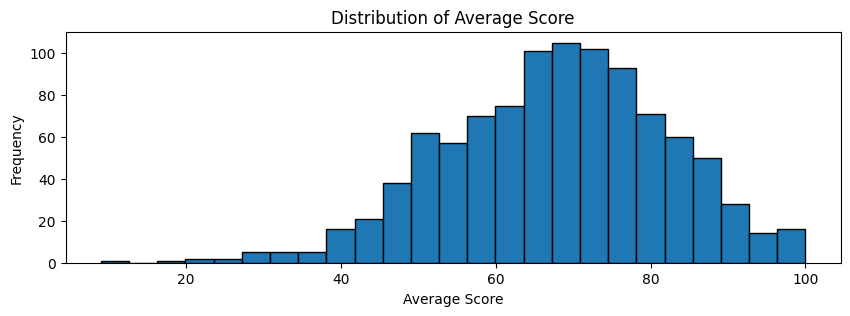

In [12]:
plt.figure(figsize=(10, 3))
plt.hist(df["average_score"], bins=25, edgecolor="black")
plt.title("Distribution of Average Score")
plt.xlabel("Average Score")
plt.ylabel("Frequency")
plt.show()

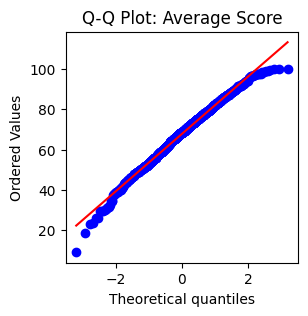

In [13]:
plt.figure(figsize=(3,3))
stats.probplot(df["average_score"], dist="norm", plot=plt)
plt.title("Q-Q Plot: Average Score")
plt.show()

# Does math score differ by gender?

In [14]:
male_math = df[df["gender"] == "male"]["math score"]
female_math = df[df["gender"] == "female"]["math score"]

print("Male mean:", male_math.mean())
print("Female mean:", female_math.mean())
print("Mean difference:", male_math.mean() - female_math.mean())

Male mean: 68.72821576763485
Female mean: 63.633204633204635
Mean difference: 5.095011134430216


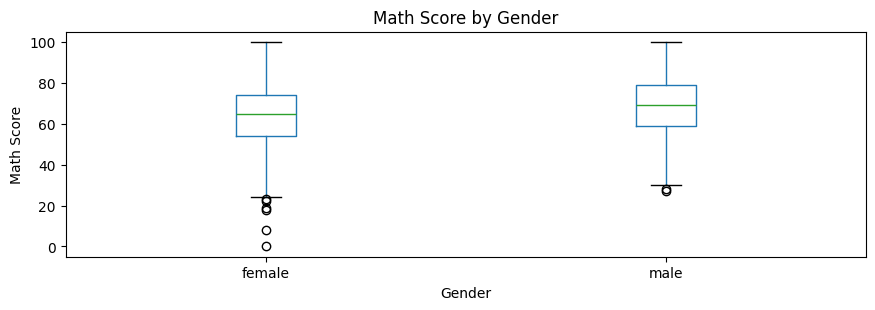

In [15]:
df.boxplot(column="math score", by="gender", figsize=(10,3), grid=False)
plt.title("Math Score by Gender"),
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Math Score")
plt.show()

In [16]:
male_shapiro = stats.shapiro(male_math)
female_shapiro = stats.shapiro(female_math)

print("Male Shapiro p-value:", male_shapiro.pvalue)
print("Female Shapiro p-value:", female_shapiro.pvalue)

Male Shapiro p-value: 0.03801760848161378
Female Shapiro p-value: 0.003509809445485069


In [17]:
if male_shapiro.pvalue >= 0.05 and female_shapiro.pvalue >= 0.05:
    print("Both group distributions are normal.")
else:
    print("At least one group may not be normally distributed.")

At least one group may not be normally distributed.


In [18]:
levene_gender = stats.levene(male_math, female_math, center="median")

print("Levene p-value:", levene_gender.pvalue)

if levene_gender.pvalue >= 0.05:
    print("Variances are similar. Use Student's t-test.")
    equal_var_gender = True
else:
    print("Variances are different. Use Welch's t-test.")
    equal_var_gender = False

Levene p-value: 0.5563091575199801
Variances are similar. Use Student's t-test.


In [19]:
u_gender = stats.mannwhitneyu(male_math, female_math, alternative="two-sided")

print("Mann-Whitney U statistic:", u_gender.statistic)
print("p-value:", u_gender.pvalue)

Mann-Whitney U statistic: 147907.5
p-value: 4.279076773478767e-07


In [20]:
def cohens_d(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    
    n1 = len(a)
    n2 = len(b)
    
    var1 = np.var(a, ddof=1)
    var2 = np.var(b, ddof=1)
    
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    return (np.mean(a) - np.mean(b)) / pooled_sd

d_gender = cohens_d(male_math, female_math)

print("Cohen's d:", d_gender)

Cohen's d: 0.34068719994699015


In [21]:
def mean_diff_ci(a, b, equal_var=True, confidence=0.95):
    a = np.asarray(a)
    b = np.asarray(b)
    
    n1 = len(a)
    n2 = len(b)
    
    mean_diff = np.mean(a) - np.mean(b)
    
    var1 = np.var(a, ddof=1)
    var2 = np.var(b, ddof=1)
    
    if equal_var:
        pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
        se = np.sqrt(pooled_var * ((1 / n1) + (1 / n2)))
        dfree = n1 + n2 - 2
    else:
        se = np.sqrt((var1 / n1) + (var2 / n2))
        dfree = ((var1 / n1) + (var2 / n2)) ** 2 / (
            ((var1 / n1) ** 2 / (n1 - 1)) + ((var2 / n2) ** 2 / (n2 - 1))
        )
    
    t_critical = stats.t.ppf((1 + confidence) / 2, dfree)
    
    lower = mean_diff - t_critical * se
    upper = mean_diff + t_critical * se
    
    return mean_diff, lower, upper

diff_gender, low_gender, high_gender = mean_diff_ci(
    male_math, 
    female_math, 
    equal_var=equal_var_gender
)

print("Mean difference:", diff_gender)
print("95% CI:", low_gender, high_gender)

Mean difference: 5.095011134430216
95% CI: 3.237736919613336 6.952285349247095


RESULT: 
The Shapiro-Wilk test showed that math scores were not normally distributed for both male and female students. Because the normality assumption was not satisfied, the Mann-Whitney U test was used instead of relying mainly on the independent samples t-test.

The Mann-Whitney U test showed a statistically significant difference in math scores between male and female students, U = 147907.5, p < .001.

Descriptively, male students had a higher average math score than female students. The mean difference was 5.10 points, with a 95% confidence interval from 3.24 to 6.95. This means that, in the population, the average math score difference is plausibly between about 3 and 7 points in favor of male students.

Cohen’s d was 0.341, which suggests a small-to-moderate effect size. Therefore, the difference is statistically significant, but the practical size of the difference is not very large.

# Does test preparation improve average score?

Note: average score is already calculated as a mean of the given subjects. See question 1.

In [22]:
completed = df[df["test preparation course"] == "completed"]["average_score"]
none = df[df["test preparation course"] == "none"]["average_score"]

In [23]:
print("Completed group size:", len(completed))
print("None group size:", len(none))

print("Completed mean:", completed.mean())
print("None mean:", none.mean())
print("Mean difference:", completed.mean() - none.mean())

print("Completed median:", completed.median())
print("None median:", none.median())

Completed group size: 358
None group size: 642
Completed mean: 72.66945996275605
None mean: 65.03894080996885
Mean difference: 7.630519152787201
Completed median: 73.5
None median: 65.33333333333333


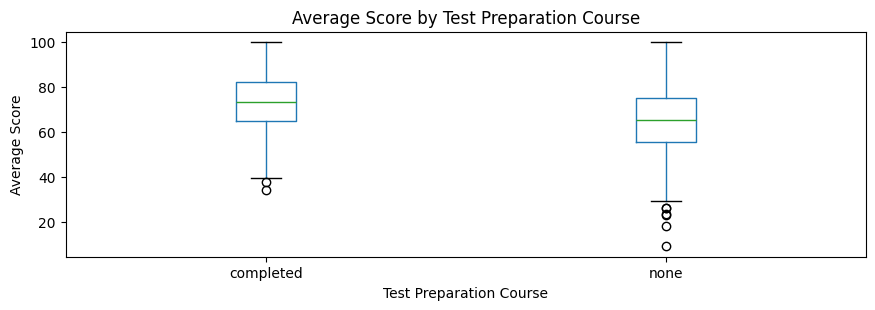

In [24]:
df.boxplot(column="average_score", by="test preparation course", grid = False, figsize=(10,3))

plt.title("Average Score by Test Preparation Course")
plt.suptitle("")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.show()

In [25]:
completed_shapiro = stats.shapiro(completed)
none_shapiro = stats.shapiro(none)

print("Completed Shapiro p-value:", completed_shapiro.pvalue)
print("None Shapiro p-value:", none_shapiro.pvalue)

if completed_shapiro.pvalue >= 0.05 and none_shapiro.pvalue >= 0.05:
    print("Both groups are normally distributed.")
else:
    print("At least one group may not be normally distributed.")

Completed Shapiro p-value: 0.02437661501476745
None Shapiro p-value: 0.008969734441098859
At least one group may not be normally distributed.


In [26]:
levene_prep = stats.levene(completed, none, center="median")

print("Levene p-value:", levene_prep.pvalue)

if levene_prep.pvalue >= 0.05:
    print("Variances are similar.")
    equal_var_prep = True
else:
    print("Variances are different.")
    equal_var_prep = False

Levene p-value: 0.08971161295284147
Variances are similar.


In [27]:
# extra code, Should already print the Man Whitney
if completed_shapiro.pvalue >= 0.05 and none_shapiro.pvalue >= 0.05:
    if equal_var_prep:
        print("Use Student's independent t-test.")
    else:
        print("Use Welch's t-test.")
else:
    print("Use Mann-Whitney U test as the main test.")

Use Mann-Whitney U test as the main test.


In [28]:
u_prep = stats.mannwhitneyu(completed, none, alternative="two-sided")

print("Mann-Whitney U statistic:", u_prep.statistic)
print("p-value:", u_prep.pvalue)

Mann-Whitney U statistic: 150319.5
p-value: 6.202995039227689e-16


In [29]:
def cohens_d(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    
    n1 = len(a)
    n2 = len(b)
    
    var1 = np.var(a, ddof=1)
    var2 = np.var(b, ddof=1)
    
    pooled_sd = np.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    )
    
    return (np.mean(a) - np.mean(b)) / pooled_sd

d_prep = cohens_d(completed, none)

print("Cohen's d:", d_prep)

Cohen's d: 0.553479854726847


In [30]:
def mean_diff_ci(a, b, equal_var=True, confidence=0.95):
    a = np.asarray(a)
    b = np.asarray(b)
    
    n1 = len(a)
    n2 = len(b)
    
    mean_diff = np.mean(a) - np.mean(b)
    
    var1 = np.var(a, ddof=1)
    var2 = np.var(b, ddof=1)
    
    if equal_var:
        pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
        se = np.sqrt(pooled_var * ((1 / n1) + (1 / n2)))
        dfree = n1 + n2 - 2
    else:
        se = np.sqrt((var1 / n1) + (var2 / n2))
        dfree = ((var1 / n1) + (var2 / n2)) ** 2 / (
            ((var1 / n1) ** 2 / (n1 - 1)) + 
            ((var2 / n2) ** 2 / (n2 - 1))
        )
    
    t_critical = stats.t.ppf((1 + confidence) / 2, dfree)
    
    lower = mean_diff - t_critical * se
    upper = mean_diff + t_critical * se
    
    return mean_diff, lower, upper

diff_prep, low_prep, high_prep = mean_diff_ci(
    completed,
    none,
    equal_var=equal_var_prep
)

print("Mean difference:", diff_prep)
print("95% CI lower:", low_prep)
print("95% CI upper:", high_prep)

Mean difference: 7.630519152787201
95% CI lower: 5.846011770601136
95% CI upper: 9.415026534973267


In [31]:
summary_prep = df.groupby("test preparation course")["average_score"].agg(["mean", "count", "std"])

summary_prep["se"] = summary_prep["std"] / np.sqrt(summary_prep["count"])
summary_prep["ci95"] = stats.t.ppf(0.975, summary_prep["count"] - 1) * summary_prep["se"]

summary_prep

,mean,count,std,se,ci95
test preparation course,,,,,
completed,72.669460,358,13.036960,0.689025,1.355058
none,65.038941,642,14.186707,0.559905,1.099469


RESULT: 
The Shapiro-Wilk test showed once again that average scores were not normally distributed in both test preparation groups: completed, p = 0.024, and none, p = 0.009. Therefore, the Mann-Whitney U test was used as the main inferential test instead of relying mainly on the independent samples t-test. Levene’s test was not significant, p = 0.090, suggesting that the variances of the two groups were reasonably similar. However, because the normality assumption was not satisfied, the nonparametric Mann-Whitney U test was preferred.

The Mann-Whitney U test showed a statistically significant difference in average scores between students who completed the test preparation course and students who did not, U = 150319.5, p < .001.

Descriptively, students who completed the test preparation course had a higher average score, M = 72.67, compared with students who did not complete the course, M = 65.04. The mean difference was 7.63 points, with a 95% confidence interval from 5.85 to 9.42.

Cohen’s d was 0.553, indicating a moderate effect size. This suggests that test preparation was associated with a statistically significant and practically meaningful improvement in average student performance.

# Does average score differ by parental education level?

In [32]:
df['parental level of education'].unique()


array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

there are more than 2 groups
Group variable = parental level of education
Numeric variable = average_score

we will follow this path:
ANOVA if assumptions are okay
Kruskal-Wallis if normality is violated
Post-hoc test if the overall test is significant

In [33]:
edu_col = "parental level of education"
value_col = "average_score"

summary_edu = df.groupby(edu_col)[value_col].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False)

summary_edu

,count,mean,median,std
parental level of education,,,,
master's degree,59,73.598870,73.333333,13.601017
bachelor's degree,118,71.923729,71.166667,13.946609
associate's degree,222,69.569069,69.666667,13.670914
some college,226,68.476401,68.666667,13.710974
some high school,179,65.108007,66.666667,14.984078
high school,196,63.096939,65.000000,13.510583


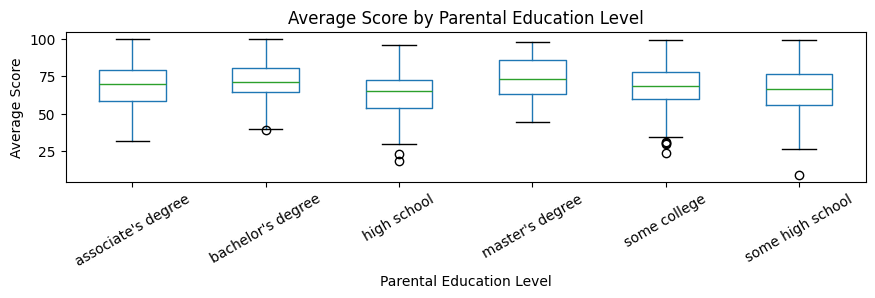

In [34]:
df.boxplot(column=value_col, by=edu_col, figsize=(10, 2), rot=30, grid =False)

plt.title("Average Score by Parental Education Level")
plt.suptitle("")
plt.xlabel("Parental Education Level")
plt.ylabel("Average Score")
plt.show()


In [35]:
education_levels = sorted(df[edu_col].unique())

groups = []

for level in education_levels:
    values = df[df[edu_col] == level][value_col]
    groups.append(values)
    
    print(level)
    print("n:", len(values))
    print("mean:", round(values.mean(), 2))
    print("median:", round(values.median(), 2))
    print("std:", round(values.std(), 2))
    print()

associate's degree
n: 222
mean: 69.57
median: 69.67
std: 13.67

bachelor's degree
n: 118
mean: 71.92
median: 71.17
std: 13.95

high school
n: 196
mean: 63.1
median: 65.0
std: 13.51

master's degree
n: 59
mean: 73.6
median: 73.33
std: 13.6

some college
n: 226
mean: 68.48
median: 68.67
std: 13.71

some high school
n: 179
mean: 65.11
median: 66.67
std: 14.98



In [36]:
normality_results = []

for level in education_levels:
    values = df[df[edu_col] == level][value_col]
    shapiro_result = stats.shapiro(values)
    
    normality_results.append([
        level,
        shapiro_result.statistic,
        shapiro_result.pvalue
    ])

normality_table = pd.DataFrame(
    normality_results,
    columns=["group", "shapiro_statistic", "shapiro_p_value"]
)

normality_table

,group,shapiro_statistic,shapiro_p_value
0,associate's degree,0.989605,0.110175
1,bachelor's degree,0.987325,0.339909
2,high school,0.988240,0.105328
3,master's degree,0.973741,0.230487
4,some college,0.987792,0.051037
5,some high school,0.979059,0.008518


In [37]:
kruskal_edu = stats.kruskal(*groups)

print("Kruskal-Wallis test")
print("H-statistic:", kruskal_edu.statistic)
print("p-value:", kruskal_edu.pvalue)

Kruskal-Wallis test
H-statistic: 44.728375524989985
p-value: 1.6475581789021656e-08


In [38]:
def epsilon_squared_kruskal(H, n, k):
    return max(0, (H - k + 1) / (n - k))

eps2_edu = epsilon_squared_kruskal(
    H=kruskal_edu.statistic,
    n=len(df),
    k=len(education_levels)
)

print("Epsilon-squared:", eps2_edu)

Epsilon-squared: 0.03996818463278671


In [39]:
edu_col = "parental level of education"
value_col = "average_score"

education_levels = sorted(df[edu_col].unique())

pairwise_results = []
raw_p_values = []

for group_1, group_2 in combinations(education_levels, 2):
    values_1 = df[df[edu_col] == group_1][value_col]
    values_2 = df[df[edu_col] == group_2][value_col]
    
    u_result = stats.mannwhitneyu(
        values_1,
        values_2,
        alternative="two-sided"
    )
    
    pairwise_results.append({
        "group_1": group_1,
        "group_2": group_2,
        "mean_1": values_1.mean(),
        "mean_2": values_2.mean(),
        "mean_difference": values_1.mean() - values_2.mean(),
        "median_1": values_1.median(),
        "median_2": values_2.median(),
        "U_statistic": u_result.statistic,
        "raw_p": u_result.pvalue
    })
    
    raw_p_values.append(u_result.pvalue)

In [40]:
def holm_adjust(p_values):
    p_values = np.asarray(p_values)
    m = len(p_values)
    
    order = np.argsort(p_values)
    adjusted = np.empty(m)
    
    running_max = 0
    
    for rank, idx in enumerate(order):
        value = (m - rank) * p_values[idx]
        running_max = max(running_max, value)
        adjusted[idx] = min(running_max, 1.0)
    
    return adjusted

In [41]:

posthoc_kw = pd.DataFrame(pairwise_results)

posthoc_kw["holm_adjusted_p"] = holm_adjust(raw_p_values)
posthoc_kw["significant"] = posthoc_kw["holm_adjusted_p"] < 0.05

posthoc_kw = posthoc_kw.sort_values("holm_adjusted_p")

posthoc_kw


,group_1,group_2,mean_1,mean_2,mean_difference,median_1,median_2,U_statistic,raw_p,holm_adjusted_p,significant
5,bachelor's degree,high school,71.923729,63.096939,8.826790,71.166667,65.000000,15491.0,4.665463e-07,0.000007,True
9,high school,master's degree,63.096939,73.598870,-10.501931,65.000000,73.333333,3484.0,3.729526e-06,0.000052,True
1,associate's degree,high school,69.569069,63.096939,6.472130,69.666667,65.000000,27218.0,9.375688e-06,0.000122,True
10,high school,some college,63.096939,68.476401,-5.379462,65.000000,68.666667,17281.0,9.830783e-05,0.001180,True
13,master's degree,some high school,73.598870,65.108007,8.490863,73.333333,66.666667,6916.0,3.635769e-04,0.003999,True
8,bachelor's degree,some high school,71.923729,65.108007,6.815721,71.166667,66.666667,13025.0,6.697989e-04,0.006698,True
4,associate's degree,some high school,69.569069,65.108007,4.461062,69.666667,66.666667,22884.0,8.978943e-03,0.080810,False
12,master's degree,some college,73.598870,68.476401,5.122469,73.333333,68.666667,7996.5,1.839095e-02,0.147128,False
14,some college,some high school,68.476401,65.108007,3.368394,68.666667,66.666667,22643.0,3.894321e-02,0.272602,False
2,associate's degree,master's degree,69.569069,73.598870,-4.029801,69.666667,73.333333,5522.0,6.426305e-02,0.336217,False


In [42]:
significant_kw_posthoc = posthoc_kw[posthoc_kw["significant"] == True]

significant_kw_posthoc

,group_1,group_2,mean_1,mean_2,mean_difference,median_1,median_2,U_statistic,raw_p,holm_adjusted_p,significant
5,bachelor's degree,high school,71.923729,63.096939,8.826790,71.166667,65.000000,15491.0,4.665463e-07,0.000007,True
9,high school,master's degree,63.096939,73.598870,-10.501931,65.000000,73.333333,3484.0,3.729526e-06,0.000052,True
1,associate's degree,high school,69.569069,63.096939,6.472130,69.666667,65.000000,27218.0,9.375688e-06,0.000122,True
10,high school,some college,63.096939,68.476401,-5.379462,65.000000,68.666667,17281.0,9.830783e-05,0.001180,True
13,master's degree,some high school,73.598870,65.108007,8.490863,73.333333,66.666667,6916.0,3.635769e-04,0.003999,True
8,bachelor's degree,some high school,71.923729,65.108007,6.815721,71.166667,66.666667,13025.0,6.697989e-04,0.006698,True


The Shapiro-Wilk normality checks showed that at least one parental education group was not normally distributed. Therefore, the Kruskal-Wallis test was used as the main inferential test.

The Kruskal-Wallis test showed a statistically significant difference in average score distributions across parental education levels, H = 44.728, p < .001. The effect size was small, epsilon² = 0.040, meaning parental education level was statistically related to student performance, but the practical size of the difference was modest.

Because the overall Kruskal-Wallis test was significant, post-hoc pairwise comparisons were conducted using pairwise Mann-Whitney U tests with Holm-adjusted p-values.

The post-hoc results showed that students whose parents had a high school education scored significantly lower than students whose parents had a bachelor’s degree, associate’s degree, master’s degree, or some college education. In addition, students whose parents had [some] high school education scored significantly lower than students whose parents had a bachelor’s degree or master’s degree.

The largest observed mean difference was between the high school and master’s degree groups. Students whose parents had a master’s degree had an average score of 73.60, while students whose parents had a high school education had an average score of 63.10, a difference of about 10.50 points.

From the results, it can be said that higher parental education levels were associated with better student performance, but the small effect size suggests that parental education explains only a limited part of the differences in scores.

# Is test preparation associated with pass/fail status?

In [43]:
df["pass_status"].unique()

array(['pass', 'fail'], dtype=object)

Note: Categorical column of pass_students is also later created using the existing columns

In [44]:
df["test preparation course"].unique()


array(['none', 'completed'], dtype=object)

We have two ccategorical columns, so chi_square should be implemented

In [45]:
contingency = pd.crosstab(
    df["test preparation course"],
    df["pass_status"]
)

contingency

pass_status,fail,pass
test preparation course,,
completed,60,298
none,225,417


In [46]:
row_percentages = contingency.div(contingency.sum(axis=1), axis=0) * 100

row_percentages.round(2)

pass_status,fail,pass
test preparation course,,
completed,16.76,83.24
none,35.05,64.95


In [47]:
chi2, chi_p, chi_dof, expected = stats.chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("p-value:", chi_p)
print("Degrees of freedom:", chi_dof)

Chi-square statistic: 36.82603026116615
p-value: 1.2915426312756866e-09
Degrees of freedom: 1


In [48]:
expected_table = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_table.round(2)

pass_status,fail,pass
test preparation course,,
completed,102.03,255.97
none,182.97,459.03


In [49]:
if (expected_table >= 5).all().all():
    print("Chi-square assumption is satisfied: all expected counts are at least 5.")
else:
    print("Warning: Some expected counts are below 5. Fisher's exact test may be better.")

Chi-square assumption is satisfied: all expected counts are at least 5.


In [50]:
n = contingency.values.sum()
min_dim = min(contingency.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dim))

print("Cramér's V:", cramers_v)

Cramér's V: 0.19190109499730884


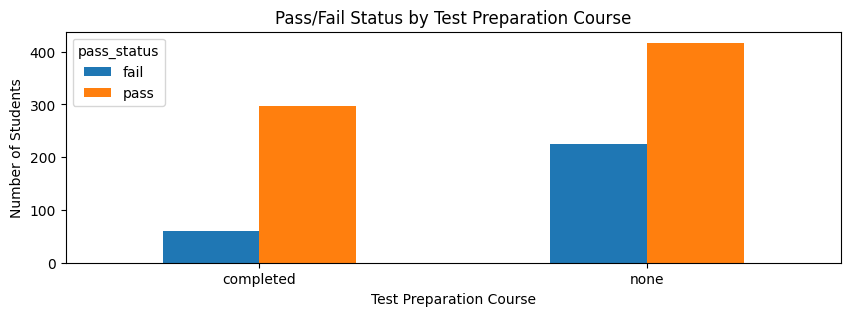

In [51]:
contingency.plot(kind="bar", figsize=(10,3))

plt.title("Pass/Fail Status by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

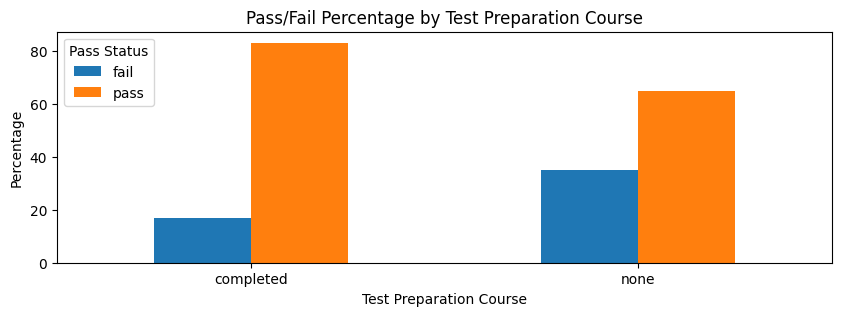

In [52]:
row_percentages.plot(kind="bar", figsize=(10,3))

plt.title("Pass/Fail Percentage by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Pass Status")
plt.show()

A chi-square test of independence was used to examine whether test preparation course completion was associated with pass/fail status.

The chi-square assumption was satisfied because all expected counts were above 5. The test showed a statistically significant association between test preparation and pass/fail status, χ²(1) = 36.826, p < .001.

Students who completed the test preparation course had a higher pass rate, 83.24%, compared with students who did not complete the course, 64.95%. The fail rate was also lower among students who completed the course, 16.76%, compared with 35.05% among students who did not.

Cramér’s V was 0.192, indicating a small-to-moderate association. This means test preparation is meaningfully related to passing status, but it is not the only factor influencing student success.

In [53]:
score_cols = ["math score", "reading score", "writing score", "average_score"]

corr = df[score_cols].corr()
corr

,math score,reading score,writing score,average_score
math score,1.000000,0.817580,0.802642,0.918746
reading score,0.817580,1.000000,0.954598,0.970331
writing score,0.802642,0.954598,1.000000,0.965667
average_score,0.918746,0.970331,0.965667,1.000000


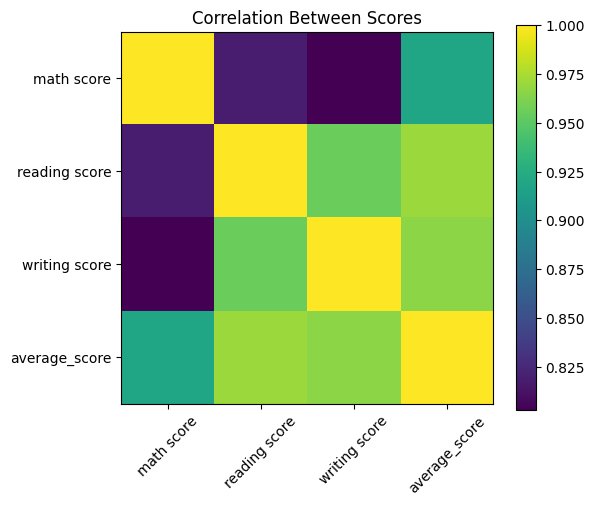

In [54]:
plt.figure(figsize=(6, 5))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(score_cols)), score_cols, rotation=45)
plt.yticks(range(len(score_cols)), score_cols)
plt.title("Correlation Between Scores")
plt.show()